In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os

In [16]:
CV_SCORES_FOLDER = "cv_scores"
MODIFIED_CVS_FOLDER = "modified_cvs"
ORIGINAL_CVS_FOLDER = "original_cvs"

# Score Correlations

First we make the first visualization from `final_figures.ipynb`, which shows the correlation in scores rated on the `Match` product manager job description between different models that modified the CV's based on I think the `DoorDash` job description. So the job description that modified the CV's and the job description that rated the CV's are not the same I think.

Also, they take a sample of 100 CV's, but I am really unsure if those are sampled from the UI/UX CV's or the Product Manager CV's or from both. I will assume they are from the Product Manager CV's for now.


In [37]:
original_cvs_df = pd.read_csv(os.path.join(ORIGINAL_CVS_FOLDER, "original_cvs.csv"), index_col=0)

scores_original_df = pd.read_csv(os.path.join(CV_SCORES_FOLDER, "original_cvs.csv"), index_col=0)
scores_sonnet_doordash_pm_df = pd.read_csv(os.path.join(CV_SCORES_FOLDER, "sonnet_doordash_pm.csv"), index_col=0)
scores_sonnet_google_ux_df = pd.read_csv(os.path.join(CV_SCORES_FOLDER, "sonnet_google_ux.csv"), index_col=0)
scores_haiku_doordash_pm_df = pd.read_csv(os.path.join(CV_SCORES_FOLDER, "haiku_doordash_pm.csv"), index_col=0)
scores_haiku_google_ux_df = pd.read_csv(os.path.join(CV_SCORES_FOLDER, "haiku_google_ux.csv"), index_col=0)
scores_opus_doordash_pm_df = pd.read_csv(os.path.join(CV_SCORES_FOLDER, "opus_doordash_pm.csv"), index_col=0)
scores_opus_google_ux_df = pd.read_csv(os.path.join(CV_SCORES_FOLDER, "opus_google_ux.csv"), index_col=0)
scores_gemini_flash_doordash_pm_df = pd.read_csv(os.path.join(CV_SCORES_FOLDER, "gemini_flash_doordash_pm.csv"), index_col=0)
scores_gemini_flash_google_ux_df = pd.read_csv(os.path.join(CV_SCORES_FOLDER, "gemini_flash_google_ux.csv"), index_col=0)
scores_gemini_pro_doordash_pm_df = pd.read_csv(os.path.join(CV_SCORES_FOLDER, "gemini_pro_doordash_pm.csv"), index_col=0)
scores_gemini_pro_google_ux_df = pd.read_csv(os.path.join(CV_SCORES_FOLDER, "gemini_pro_google_ux.csv"), index_col=0)

In [28]:
scores_sonnet_doordash_pm_df.head()

,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_doordash_pm_Raw_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_doordash_pm_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_apple_pm_Raw_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_apple_pm_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_samsara_pm_Raw_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_samsara_pm_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_yelp_pm_Raw_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_yelp_pm_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_match_pm_Raw_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_match_pm_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_i2c_ux_Raw_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_i2c_ux_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_adobe_ux_Raw_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_adobe_ux_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_amazon_ux_Raw_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_amazon_ux_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_rowan_ux_Raw_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_rowan_ux_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_google_ux_Raw_Score,Modified_claude-sonnet-4-5_of_CV_Modelclaude-sonnet-4-5_google_ux_Score
6018,0.666464,0.833232,0.660240,0.830120,0.599987,0.799994,0.646008,0.823004,0.682059,0.841030,0.749411,0.874705,0.706386,0.853193,0.776243,0.888122,0.742591,0.871295,0.765526,0.882763
6021,0.671030,0.835515,0.606809,0.803404,0.589709,0.794855,0.604296,0.802148,0.610873,0.805436,0.702577,0.851288,0.614431,0.807216,0.666847,0.833423,0.684069,0.842035,0.684917,0.842458
6026,0.637196,0.818598,0.635816,0.817908,0.550195,0.775097,0.601986,0.800993,0.682910,0.841455,0.757415,0.878707,0.730190,0.865095,0.745026,0.872513,0.703015,0.851507,0.755858,0.877929
9479,0.645914,0.822957,0.608512,0.804256,0.524920,0.762460,0.581051,0.790525,0.658117,0.829059,0.743351,0.871676,0.717724,0.858862,0.727536,0.863768,0.725741,0.862870,0.764729,0.882364
16980,0.710544,0.855272,0.744324,0.872162,0.673945,0.836972,0.719302,0.859651,0.717878,0.858939,0.705200,0.852600,0.711791,0.855896,0.749880,0.874940,0.760081,0.880041,0.732347,0.866173


In [38]:
def select_and_rename_by_substr(df, substr, new_name):
    col = df.filter(like=substr).columns[0]
    return df[[col]].rename(columns={col: new_name})


scores_combined_df = pd.concat(
    [
        original_cvs_df[["Position Group"]].rename(columns={"Position Group": "Group"}),

        select_and_rename_by_substr(
            scores_original_df,
            "match_pm_Score",
            "Original_PM_Score",
        ),

        select_and_rename_by_substr(
            scores_sonnet_doordash_pm_df,
            "match_pm_Score",
            "Sonnet_Doordash_PM_Score",
        ),

        select_and_rename_by_substr(
            scores_haiku_doordash_pm_df,
            "match_pm_Score",
            "Haiku_Doordash_PM_Score",
        ),

        select_and_rename_by_substr(
            scores_opus_doordash_pm_df,
            "match_pm_Score",
            "Opus_Doordash_PM_Score",
        ),

        select_and_rename_by_substr(
            scores_gemini_flash_doordash_pm_df,
            "match_pm_Score",
            "Gemini_Flash_Doordash_PM_Score",
        ),

        select_and_rename_by_substr(
            scores_gemini_pro_doordash_pm_df,
            "match_pm_Score",
            "Gemini_Pro_Doordash_PM_Score",
        ),
    ],
    axis=1,
    join="outer",
)


In [39]:
scores_combined_only_pm_df = scores_combined_df[scores_combined_df["Group"] == "Project Manager"].drop(columns=["Group"])

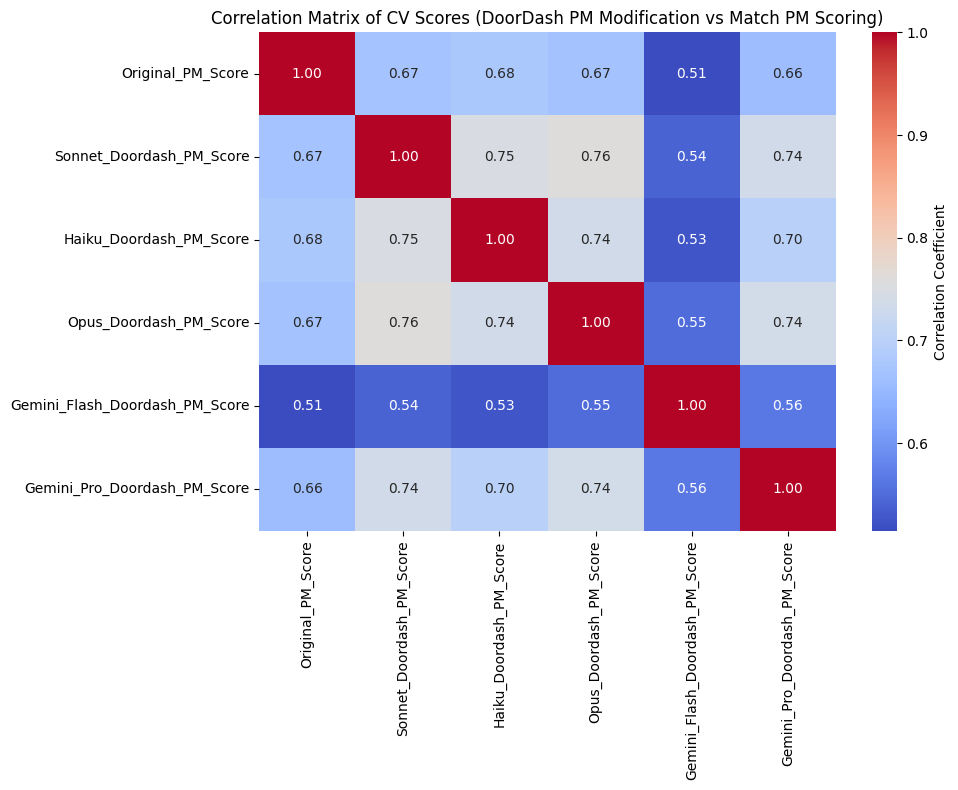

In [40]:
# Make a correlation plot for all models and original
plt.figure(figsize=(10, 8))
correlation_matrix = scores_combined_only_pm_df.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={"label": "Correlation Coefficient"},
)
plt.title("Correlation Matrix of CV Scores (DoorDash PM Modification vs Match PM Scoring)")
plt.tight_layout()
plt.show()